In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv(r'E:\Rnw\algorithms\Superviced learning\practical exam\creditcard.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
from sklearn.model_selection import train_test_split

sample_proportion = 50000 / len(df)

df_sampled, _ = train_test_split(
    df, 
    train_size=sample_proportion, 
    stratify=df['Class'], 
    random_state=42
)

print("Original Dataset Class Distribution:")
print(df['Class'].value_counts(normalize=True))

print("\nSampled Dataset Class Distribution:")
print(df_sampled['Class'].value_counts(normalize=True))

print(f"\nSampled dataset shape: {df_sampled.shape}")

Original Dataset Class Distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Sampled Dataset Class Distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

Sampled dataset shape: (50000, 31)


In [7]:
df_sampled['Class'].value_counts()

Class
0    49914
1       86
Name: count, dtype: int64

In [8]:
df_sampled.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,94977.93554,0.001813,-0.003654,-0.002152,0.007657,0.012340,0.000112,-0.008224,0.003051,0.009234,...,-0.004068,0.000101,0.001169,-0.000418,-0.003880,0.001839,0.001699,0.000330,86.942063,0.001720
std,47475.50731,1.964773,1.656783,1.510070,1.412869,1.350601,1.322614,1.201751,1.197353,1.103503,...,0.723433,0.725150,0.629551,0.607581,0.520451,0.483977,0.398520,0.303251,226.984602,0.041438
min,0.00000,-46.855047,-48.060856,-31.103685,-5.519697,-28.815577,-20.869626,-43.557242,-50.420090,-13.320155,...,-22.889347,-8.887017,-30.269720,-2.836627,-6.429334,-1.726928,-9.543518,-8.307955,0.000000,0.000000
25%,54423.50000,-0.916605,-0.601309,-0.893155,-0.832265,-0.688585,-0.767552,-0.556049,-0.204734,-0.635840,...,-0.228568,-0.551068,-0.161378,-0.355935,-0.319120,-0.328322,-0.070496,-0.052183,5.850000,0.000000
50%,84852.00000,0.025321,0.069204,0.176578,-0.016589,-0.051197,-0.274144,0.041195,0.023620,-0.044969,...,-0.027577,0.006879,-0.009182,0.041529,0.014600,-0.047669,0.001685,0.011445,22.000000,0.000000
75%,139392.25000,1.316058,0.804474,1.021558,0.746497,0.623882,0.398315,0.572980,0.326023,0.602138,...,0.184405,0.525397,0.148595,0.440056,0.345071,0.243678,0.092917,0.078415,76.275000,0.000000
max,172787.00000,2.420346,22.057729,4.101716,13.129143,29.162172,21.190194,26.249717,20.007208,10.370658,...,27.202839,8.316275,17.751731,4.016342,5.852484,3.517346,9.879903,15.870474,8360.000000,1.000000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

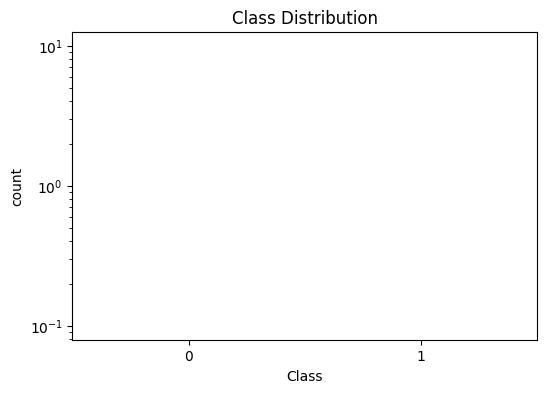

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_sampled,log_scale=True)
plt.title('Class Distribution')
plt.show()

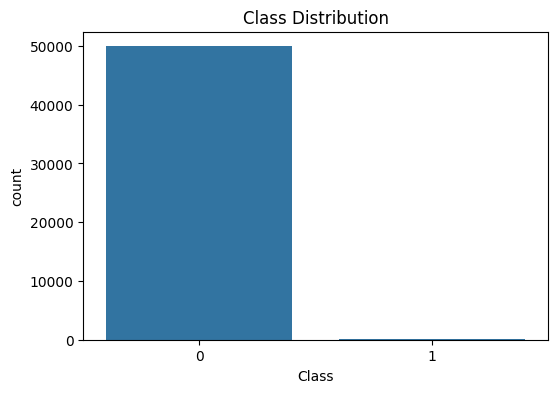

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_sampled)
plt.title('Class Distribution')
plt.show()

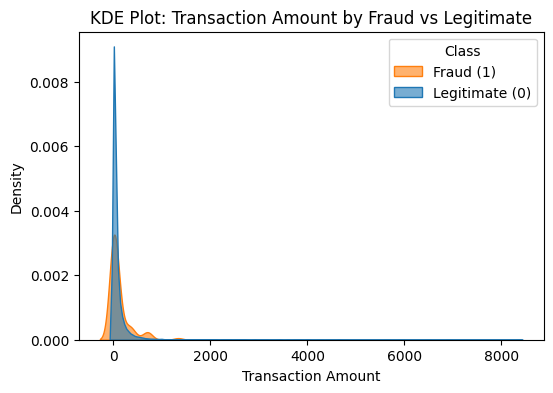

In [12]:

plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_sampled, x='Amount', hue='Class', fill=True, common_norm=False, alpha=0.6)

plt.title('KDE Plot: Transaction Amount by Fraud vs Legitimate')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.legend(title='Class', labels=['Fraud (1)', 'Legitimate (0)'])
plt.show()

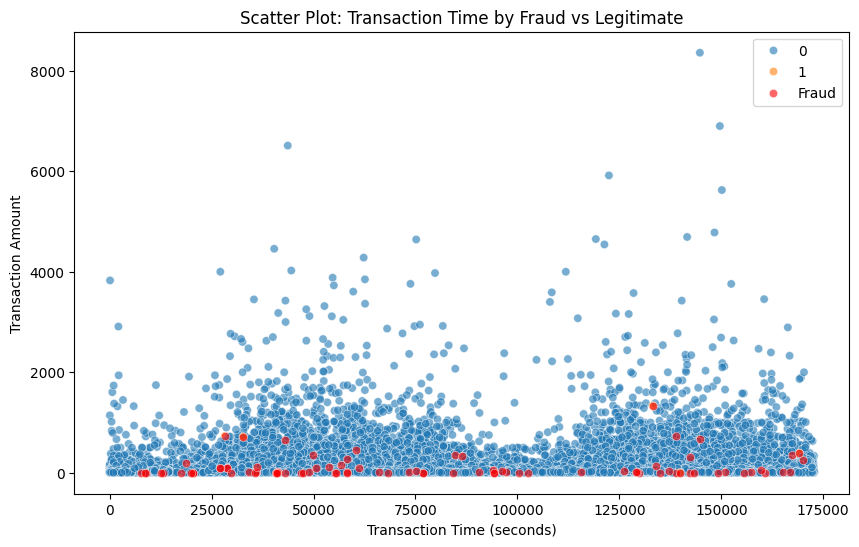

In [13]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sampled, x='Time', y='Amount', hue='Class', alpha=0.6)
sns.scatterplot(data=df_sampled[df_sampled['Class'] == 1], x='Time', y='Amount', color='red', label='Fraud', alpha=0.6)
plt.title('Scatter Plot: Transaction Time by Fraud vs Legitimate')
plt.xlabel('Transaction Time (seconds)')
plt.ylabel('Transaction Amount')
plt.show()

In [14]:
df_sampled.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

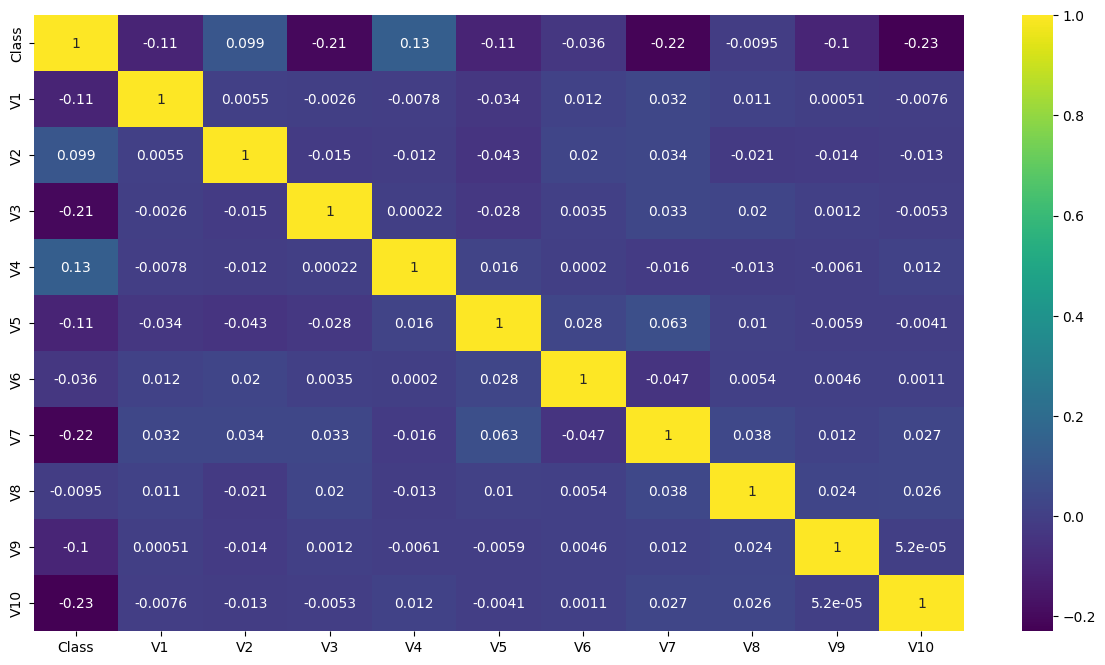

In [15]:
selected_cols = ['Class','V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']  
plt.figure(figsize=(15, 8))
sns.heatmap(df_sampled[selected_cols].corr(), annot=True, cmap='viridis')
plt.show()

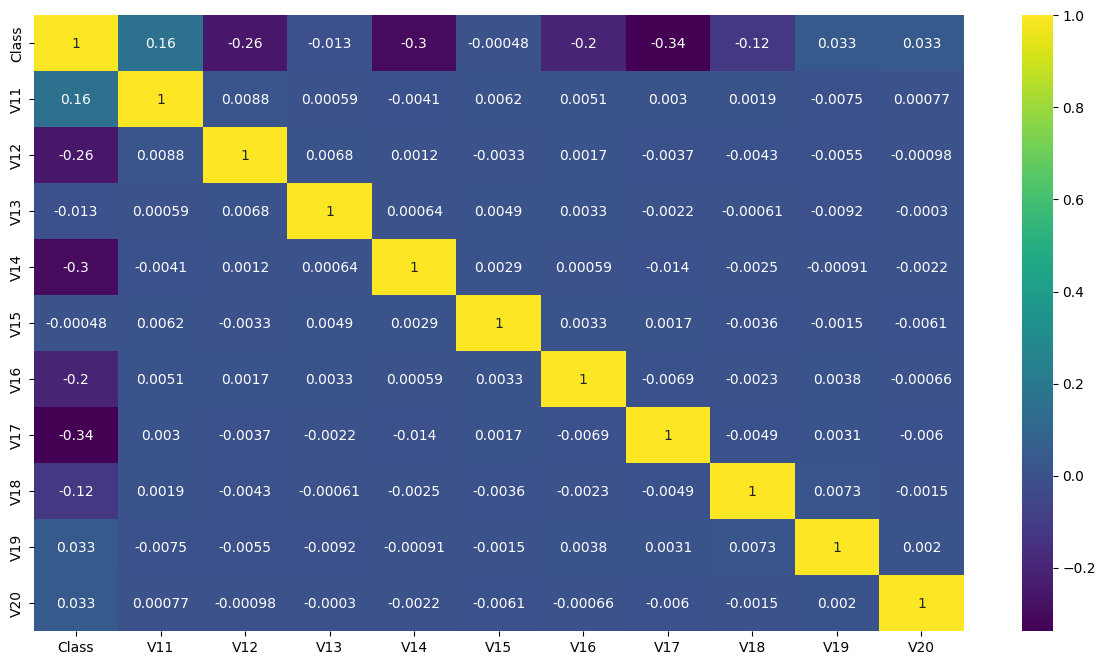

In [16]:
selected_cols = ['Class','V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20']  
plt.figure(figsize=(15, 8))
sns.heatmap(df_sampled[selected_cols].corr(), annot=True, cmap='viridis')
plt.show()

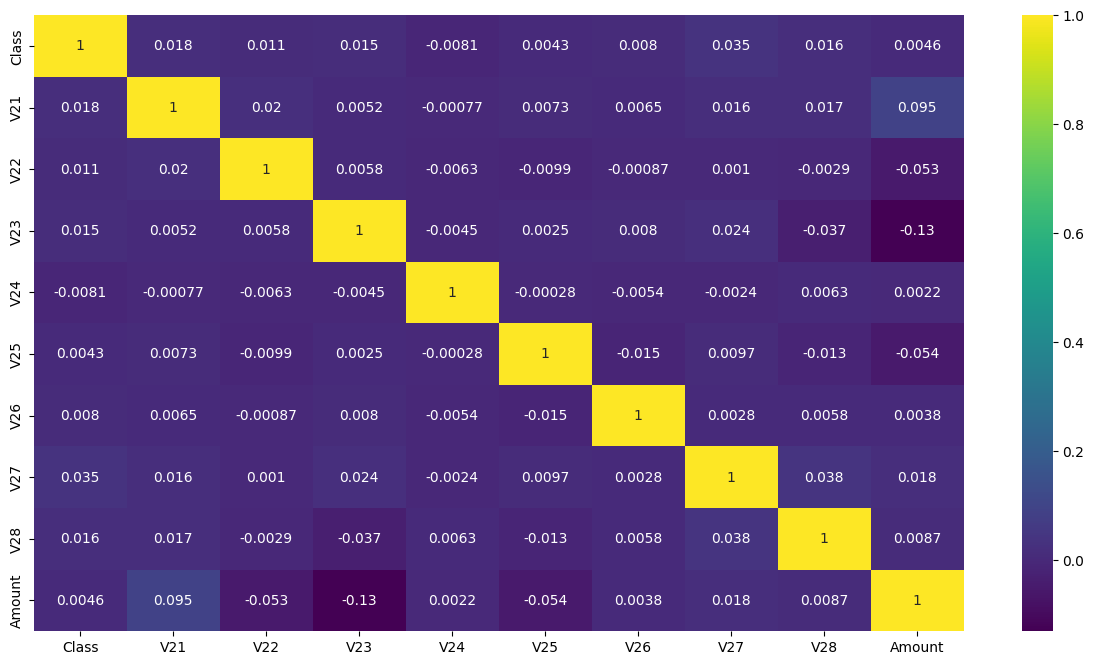

In [17]:
selected_cols = ['Class','V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']  
plt.figure(figsize=(15, 8))
sns.heatmap(df_sampled[selected_cols].corr(), annot=True, cmap='viridis')
plt.show()

In [18]:
df['Amount_log'] = np.log1p(df['Amount'])

In [19]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539


In [20]:
df['hour'] = (df['Time'] // 3600) % 24

In [21]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.0


In [22]:
df.drop(columns=['Time', 'Amount'], inplace=True)


In [23]:
x = df.drop(columns=['Class'])
y = df['Class']

In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print("--- Class Distribution Verification ---")
print("Train Set Class Distribution (%):")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Set Class Distribution (%):")
print(y_test.value_counts(normalize=True) * 100)

print("\n--- Exact Class Counts ---")
print(f"Train Set Counts:\n{y_train.value_counts()}")
print(f"\nTest Set Counts:\n{y_test.value_counts()}")

--- Class Distribution Verification ---
Train Set Class Distribution (%):
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Test Set Class Distribution (%):
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64

--- Exact Class Counts ---
Train Set Counts:
Class
0    227451
1       394
Name: count, dtype: int64

Test Set Counts:
Class
0    56864
1       98
Name: count, dtype: int64


In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [26]:
print("--- Original Training Set ---")
print(pd.Series(y_train).value_counts())
print("\n")

--- Original Training Set ---
Class
0    227451
1       394
Name: count, dtype: int64




In [27]:
smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("--- SMOTE Training Set ---")
print(pd.Series(y_smote).value_counts())
print("\n")

--- SMOTE Training Set ---
Class
0    227451
1     22745
Name: count, dtype: int64




In [28]:
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.1)
X_under, y_under = rus.fit_resample(X_train, y_train)

print("--- Undersampled Training Set ---")
print(pd.Series(y_under).value_counts())

--- Undersampled Training Set ---
Class
0    3940
1     394
Name: count, dtype: int64


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

lr_orig = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42).fit(X_train, y_train)

preds_orig, probs_orig = lr_orig.predict(X_test), lr_orig.predict_proba(X_test)[:, 1]

p_orig, r_orig, f_orig, _ = precision_recall_fscore_support(y_test, preds_orig, pos_label=1, average='binary')

ap_orig = average_precision_score(y_test, probs_orig)


In [32]:
lr_smote = LogisticRegression(class_weight=None, max_iter=1000, random_state=42).fit(X_smote, y_smote)

preds_smote, probs_smote = lr_smote.predict(X_test), lr_smote.predict_proba(X_test)[:, 1]

p_smote, r_smote, f_smote, _ = precision_recall_fscore_support(y_test, preds_smote, pos_label=1, average='binary')

ap_smote = average_precision_score(y_test, probs_smote)

In [33]:

lr_under = LogisticRegression(class_weight=None, max_iter=1000, random_state=42).fit(X_under, y_under)

preds_under, probs_under = lr_under.predict(X_test), lr_under.predict_proba(X_test)[:, 1]

p_under, r_under, f_under, _ = precision_recall_fscore_support(y_test, preds_under, pos_label=1, average='binary')

ap_under = average_precision_score(y_test, probs_under)


In [34]:
import pandas as pd
data = {'Metric': ['Precision', 'Recall', 'F1-Score', 'PR-AUC'],
        'Original (Balanced)': [p_orig, r_orig, f_orig, ap_orig],
        'SMOTE': [p_smote, r_smote, f_smote, ap_smote],
        'Undersampled': [p_under, r_under, f_under, ap_under]}
print(pd.DataFrame(data).set_index('Metric').round(4))

           Original (Balanced)   SMOTE  Undersampled
Metric                                              
Precision               0.0553  0.3551        0.3398
Recall                  0.9082  0.8878        0.8878
F1-Score                0.1043  0.5073        0.4915
PR-AUC                  0.7129  0.7435        0.7456


In [35]:

f1_scores = {'Original (Balanced)': f_orig, 'SMOTE': f_smote, 'Undersampled': f_under}

best_strategy = max(f1_scores, key=f1_scores.get)

print(f"Best Imbalance Strategy based on Fraud class F1-Score: {best_strategy}")

print("Note: PR-AUC should also be heavily considered for highly imbalanced fraud datasets.")

Best Imbalance Strategy based on Fraud class F1-Score: SMOTE
Note: PR-AUC should also be heavily considered for highly imbalanced fraud datasets.


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_smote, y_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

rf_preds, rf_probs = rf_model.predict(X_test), rf_model.predict_proba(X_test)[:, 1]
p_rf, r_rf, f_rf, _ = precision_recall_fscore_support(y_test, rf_preds, pos_label=1, average='binary')
prauc_rf = average_precision_score(y_test, rf_probs)

print(f"Random Forest Metrics:\nPrecision: {p_rf:.4f}\nRecall: {r_rf:.4f}\nF1-Score: {f_rf:.4f}\nPR-AUC: {prauc_rf:.4f}")

Random Forest Metrics:
Precision: 0.8791
Recall: 0.8163
F1-Score: 0.8466
PR-AUC: 0.8688


<Figure size 1000x600 with 0 Axes>

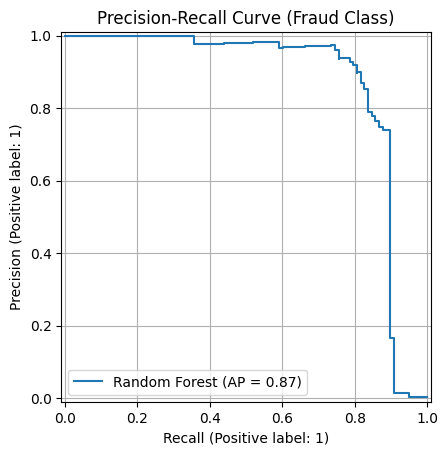

In [43]:
from sklearn.metrics import PrecisionRecallDisplay
plt.figure(figsize=(10, 6))
PrecisionRecallDisplay.from_predictions(y_test, rf_probs, name="Random Forest")
plt.title("Precision-Recall Curve (Fraud Class)")
plt.grid(True)
plt.show()

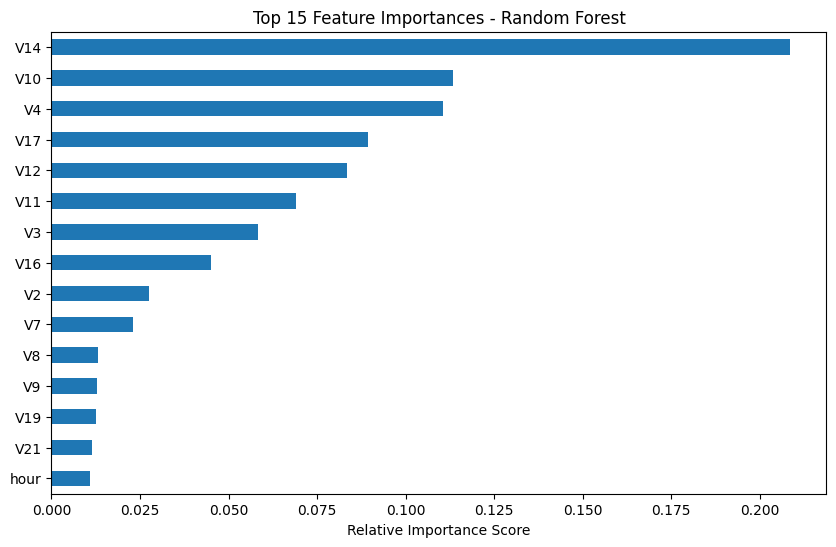

In [40]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(10, 6)).invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Relative Importance Score")
plt.show()

In [44]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.1 MB/s eta 0:00:33
   ---------------------------------------- 0.8/69.5 MB 1.8 MB/s eta 0:00:39
    --------------------------------------- 1.3/69.5 MB 1.9 MB/s eta 0:00:37
   - -------------------------------------- 1.8/69.5 MB 2.0 MB/s eta 0:00:34
   - -------------------------------------- 2.4/69.5 MB 2.1 MB/s eta 0:00:32
   - -------------------------------------- 2.6/69.5 MB 2.1 MB/s eta 0:00:32
   - -------------------------------------- 3.1/69.5 MB 2.2 MB/s eta 0:00:30
   -- ------------------------------------- 3.7/69.5 MB 2.2 MB/s eta 0:00:30
   -- ------------------------------------- 4.5/69.5 MB 2.3 MB/s eta 0:00:28
   -- ------------------------------------- 5.0/69.5 MB 2.4 MB/s eta 0:00:28
   --- -------------

In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_fscore_support, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_baseline = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=4, 
    scale_pos_weight=ratio, 
    random_state=42,
    eval_metric='logloss'
)
xgb_baseline.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [46]:
xgb_preds = xgb_baseline.predict(X_test)
xgb_probs = xgb_baseline.predict_proba(X_test)[:, 1]

precision, recall, f1, _ = precision_recall_fscore_support(y_test, xgb_preds, pos_label=1, average='binary')
pr_auc = average_precision_score(y_test, xgb_probs)

print("--- XGBoost Baseline Performance ---")
print(f"Calculated Imbalance Ratio: {ratio:.2f}")
print(f"Precision (Fraud):          {precision:.4f}")
print(f"Recall (Fraud):             {recall:.4f}")
print(f"F1-Score (Fraud):           {f1:.4f}")
print(f"PR-AUC:                     {pr_auc:.4f}")

--- XGBoost Baseline Performance ---
Calculated Imbalance Ratio: 577.29
Precision (Fraud):          0.5850
Recall (Fraud):             0.8776
F1-Score (Fraud):           0.7020
PR-AUC:                     0.8614


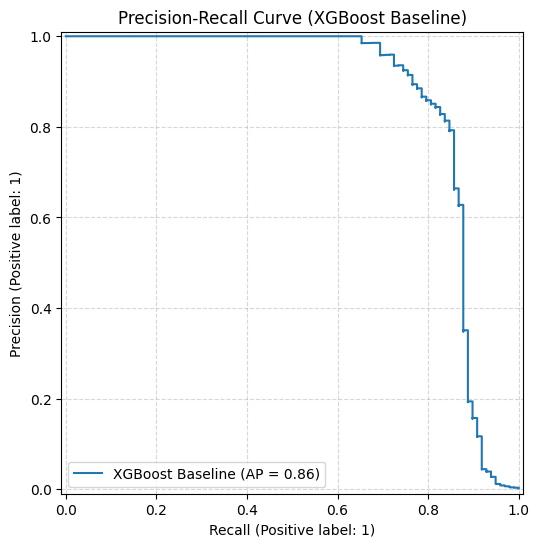

In [47]:
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, xgb_probs, name="XGBoost Baseline", ax=plt.gca())
plt.title("Precision-Recall Curve (XGBoost Baseline)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_base = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

print("--- Hyperparameter Tuning Results ---")
print(f"Best Parameters Found: {xgb_random.best_params_}")
print(f"Best CV PR-AUC (Average Precision): {xgb_random.best_score_:.4f}\n")

--- Hyperparameter Tuning Results ---
Best Parameters Found: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV PR-AUC (Average Precision): 0.8429



In [49]:
from sklearn.metrics import average_precision_score

xgb_tuned = xgb_random.best_estimator_

xgb_tuned_probs = xgb_tuned.predict_proba(X_test)[:, 1]

pr_auc_tuned = average_precision_score(y_test, xgb_tuned_probs)

print("--- PR-AUC Comparison ---")
print(f"XGBoost Baseline PR-AUC: {pr_auc:.4f}")
print(f"XGBoost Tuned PR-AUC:    {pr_auc_tuned:.4f}")
print(f"Absolute Improvement:    {pr_auc_tuned - pr_auc:.4f}")

--- PR-AUC Comparison ---
XGBoost Baseline PR-AUC: 0.8614
XGBoost Tuned PR-AUC:    0.8475
Absolute Improvement:    -0.0139


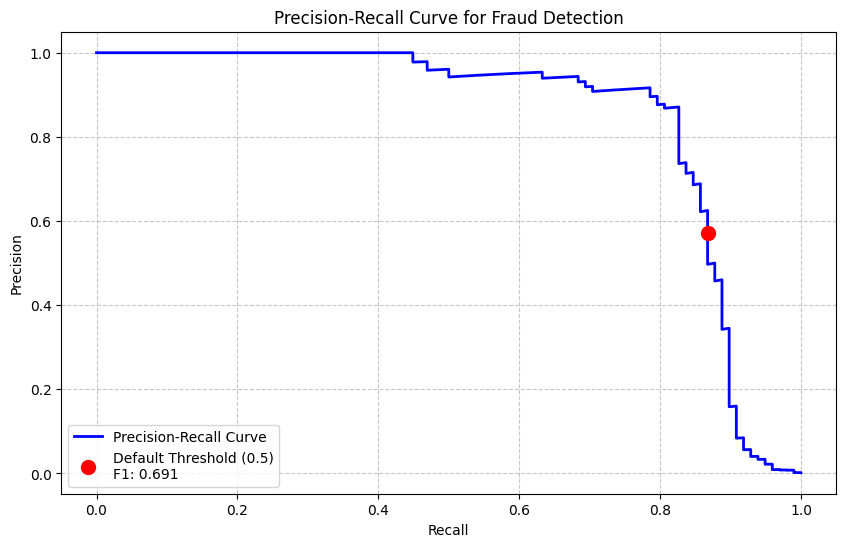

Optimal Threshold (Max F1-Score): 0.9708
Optimal Threshold (Recall >= 0.90): 0.0642

THRESHOLD COMPARISON

--- Metrics for Default Cutoff (Threshold: 0.5000) ---
Precision: 0.5743
Recall:    0.8673
F1-Score:  0.6911

--- Metrics for Max F1-Score Strategy (Threshold: 0.9708) ---
Precision: 0.8710
Recall:    0.8265
F1-Score:  0.8482

--- Metrics for High Recall (>=0.90) Strategy (Threshold: 0.0642) ---
Precision: 0.1601
Recall:    0.9082
F1-Score:  0.2722


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, classification_report

y_probs = xgb_tuned.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, label='Precision-Recall Curve', color='blue', lw=2)

default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(recalls[default_idx], precisions[default_idx], 'ro', markersize=10, 
         label=f'Default Threshold (0.5)\nF1: {f1_score(y_test, y_probs >= 0.5):.3f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Fraud Detection')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
f1_scores = np.nan_to_num(f1_scores) 

best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]
print(f"Optimal Threshold (Max F1-Score): {best_f1_threshold:.4f}")


valid_indices = np.where(recalls[:-1] >= 0.90)[0]

best_prec_idx = valid_indices[np.argmax(precisions[:-1][valid_indices])]
high_recall_threshold = thresholds[best_prec_idx]
print(f"Optimal Threshold (Recall >= 0.90): {high_recall_threshold:.4f}")

def evaluate_custom_threshold(y_true, probs, threshold, strategy_name):
    """Helper function to print evaluation metrics for a specific threshold."""
    y_pred = (probs >= threshold).astype(int)
    print(f"\n--- Metrics for {strategy_name} (Threshold: {threshold:.4f}) ---")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

print("\n" + "="*50)
print("THRESHOLD COMPARISON")
print("="*50)
evaluate_custom_threshold(y_test, y_probs, 0.5, "Default Cutoff")
evaluate_custom_threshold(y_test, y_probs, best_f1_threshold, "Max F1-Score Strategy")
evaluate_custom_threshold(y_test, y_probs, high_recall_threshold, "High Recall (>=0.90) Strategy")